# E-commerce User Interest Prediction
## Machine Learning vs Deep Learning from Scratch bằng NumPy

**Dataset:** Women's Clothing E-Commerce Reviews

**Bài toán:** Binary Classification — dự đoán **user interest / recommendation** thông qua biến `Recommended IND`.

- `0` → Not Interested / không recommend
- `1` → Interested / recommend

> Lưu ý: notebook giữ `Recommended IND` làm **target**, không sử dụng nó làm input feature. Các trường `Rating`, `Title`, `Review Text` được dùng để xây dựng feature vì chúng có sẵn tại thời điểm dự đoán.


In [1]:
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (10, 5)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.5.2
Pandas: 3.0.5


## 1. Dataset and Problem Definition

| Application | Problem | Target |
|---|---|---|
| E-commerce | User Interest / Recommendation Prediction | `Recommended IND` |

**Mục tiêu:** từ thông tin khách hàng, sản phẩm và review, dự đoán xác suất người dùng quan tâm/recommend sản phẩm.

**Đánh giá:** Accuracy, Precision, Recall, F1-score và ROC-AUC.


In [2]:
DATA_PATH = "data/Womens Clothing E-Commerce Reviews.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head())


Shape: (23486, 11)

Columns:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 2. Data Inspection and Understanding

Kiểm tra:
- kích thước dữ liệu;
- kiểu dữ liệu;
- missing values;
- duplicate records;
- thống kê mô tả;
- phân bố target;
- các nhóm numerical / categorical / text.


In [3]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== HEAD ===")
display(df.head())

print("\n=== INFO ===")
df.info()

print("\n=== DESCRIBE ===")
display(df.describe(include="all").T)

print("\n=== MISSING VALUES ===")
display(df.isna().sum().sort_values(ascending=False))

print("\n=== DUPLICATES ===")
print(df.duplicated().sum())

print("\n=== TARGET ===")
print(df["Recommended IND"].value_counts(dropna=False))
print(df["Recommended IND"].value_counts(normalize=True).round(4))


=== SHAPE ===
(23486, 11)

=== HEAD ===


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB

=== DESCRIBE ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,NaN,NaN,NaN,11742.5,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== MISSING VALUES ===


Title                      3810
Review Text                 845
Department Name              14
Class Name                   14
Division Name                14
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
dtype: int64


=== DUPLICATES ===
0

=== TARGET ===
Recommended IND
1    19314
0     4172
Name: count, dtype: int64
Recommended IND
1    0.8224
0    0.1776
Name: proportion, dtype: float64


In [4]:
# Xác định nhóm feature
numeric_candidates = ["Age", "Clothing ID", "Rating"]
categorical_candidates = ["Division Name", "Department Name", "Class Name"]
text_candidates = ["Title", "Review Text"]

print("Numerical:", [c for c in numeric_candidates if c in df.columns])
print("Categorical:", [c for c in categorical_candidates if c in df.columns])
print("Text:", [c for c in text_candidates if c in df.columns])
print("Target: Recommended IND")


Numerical: ['Age', 'Clothing ID', 'Rating']
Categorical: ['Division Name', 'Department Name', 'Class Name']
Text: ['Title', 'Review Text']
Target: Recommended IND


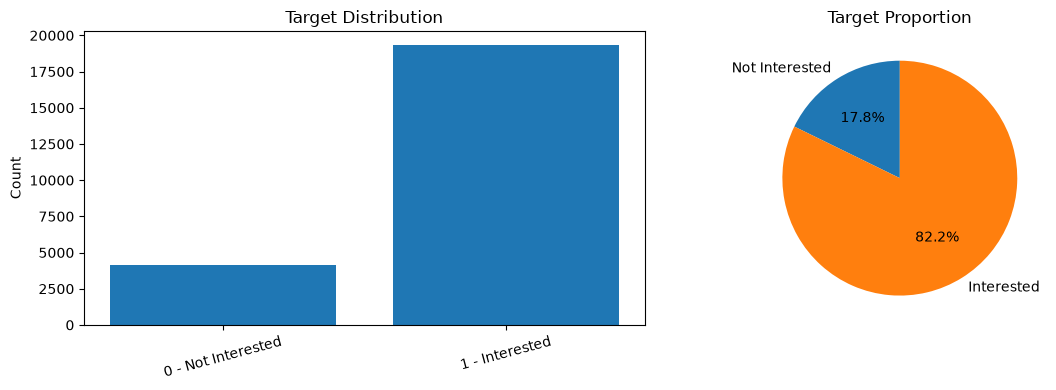

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df["Recommended IND"].value_counts().sort_index()
axes[0].bar(["0 - Not Interested", "1 - Interested"], target_counts.values)
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

axes[1].pie(target_counts.values, labels=["Not Interested", "Interested"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Target Proportion")

plt.tight_layout()
plt.show()


## 3. Data Cleaning

Quy trình:
1. bỏ cột index dư `Unnamed: 0` nếu tồn tại;
2. loại duplicate;
3. xử lý missing numerical bằng median;
4. xử lý missing categorical bằng mode;
5. xử lý missing text bằng chuỗi rỗng;
6. loại giá trị `Age <= 0`;
7. kiểm tra range của `Rating`;
8. chuẩn hóa text.


In [6]:
df = df.copy()

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Removed duplicates:", before - len(df))

# Numerical
if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df = df[df["Age"] > 0].copy()

if "Clothing ID" in df.columns:
    df["Clothing ID"] = pd.to_numeric(df["Clothing ID"], errors="coerce")
    df["Clothing ID"] = df["Clothing ID"].fillna(df["Clothing ID"].median())

if "Rating" in df.columns:
    df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
    df["Rating"] = df["Rating"].fillna(df["Rating"].median())
    df = df[df["Rating"].between(1, 5)].copy()

# Categorical
for col in ["Division Name", "Department Name", "Class Name"]:
    if col in df.columns:
        mode = df[col].mode(dropna=True)
        fill_value = mode.iloc[0] if len(mode) else "Unknown"
        df[col] = df[col].fillna(fill_value).astype(str).str.strip()

# Text
for col in ["Title", "Review Text"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

print("Final shape:", df.shape)
print("\nRemaining missing:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Removed duplicates: 21
Final shape: (23465, 10)

Remaining missing:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


## 4. Feature Engineering

Tạo:
- `combined_text`: ghép `Title` + `Review Text`;
- `review_length`: số ký tự review;
- `review_word_count`: số từ;
- `title_length`: số ký tự title.

Text được lowercase, loại ký tự không cần thiết và chuẩn hóa khoảng trắng.


In [7]:
def clean_text(text):
    text = "" if not isinstance(text, str) else text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["combined_text"] = (
    df["Title"].fillna("") + " " + df["Review Text"].fillna("")
).apply(clean_text)

df["review_length"] = df["Review Text"].str.len()
df["review_word_count"] = df["Review Text"].apply(lambda x: len(x.split()))
df["title_length"] = df["Title"].str.len()

display(df[[
    "Age", "Rating", "review_length",
    "review_word_count", "title_length",
    "combined_text", "Recommended IND"
]].head())


,Age,Rating,review_length,review_word_count,title_length,combined_text,Recommended IND
0,33,4,53,8,0,absolutely wonderful silky and sexy and comfor...,1
1,34,5,303,62,0,love this dress it s sooo pretty i happened to...,1
2,60,3,500,98,23,some major design flaws i had such high hopes ...,0
3,50,5,124,22,16,my favorite buy i love love love this jumpsuit...,1
4,47,5,192,36,16,flattering shirt this shirt is very flattering...,1


## 5. Train / Validation / Test Split

Sử dụng:
- 70% Train
- 15% Validation
- 15% Test

`stratify=y` để giữ tỷ lệ hai lớp tương đối ổn định.


In [8]:
feature_cols = [
    "Age", "Clothing ID", "Rating",
    "Division Name", "Department Name", "Class Name",
    "combined_text", "review_length", "review_word_count", "title_length"
]

X_raw = df[feature_cols].copy()
y = df["Recommended IND"].astype(int).to_numpy()

X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

print("Train:", X_train_raw.shape, Counter(y_train))
print("Val:  ", X_val_raw.shape, Counter(y_val))
print("Test: ", X_test_raw.shape, Counter(y_test))


Train: (16424, 10) Counter({np.int64(1): 13504, np.int64(0): 2920})
Val:   (3521, 10) Counter({np.int64(1): 2895, np.int64(0): 626})
Test:  (3520, 10) Counter({np.int64(1): 2894, np.int64(0): 626})


## 6. Build Feature Matrix

Preprocessing được fit **chỉ trên training set** để tránh data leakage.

- Numerical → StandardScaler
- Categorical → One-Hot Encoding
- Text → TF-IDF, tối đa 500 features
- Sau đó nối tất cả thành một dense NumPy matrix.


In [9]:
num_cols = ["Age", "Clothing ID", "Rating", "review_length",
            "review_word_count", "title_length"]
cat_cols = ["Division Name", "Department Name", "Class Name"]

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_val_num = scaler.transform(X_val_raw[num_cols])
X_test_num = scaler.transform(X_test_raw[num_cols])

# Compatible with different sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_cat = ohe.fit_transform(X_train_raw[cat_cols].astype(str))
X_val_cat = ohe.transform(X_val_raw[cat_cols].astype(str))
X_test_cat = ohe.transform(X_test_raw[cat_cols].astype(str))

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=3)
X_train_txt = tfidf.fit_transform(X_train_raw["combined_text"]).toarray()
X_val_txt = tfidf.transform(X_val_raw["combined_text"]).toarray()
X_test_txt = tfidf.transform(X_test_raw["combined_text"]).toarray()

X_train_ml = np.hstack([X_train_num, X_train_cat, X_train_txt]).astype(np.float32)
X_val_ml = np.hstack([X_val_num, X_val_cat, X_val_txt]).astype(np.float32)
X_test_ml = np.hstack([X_test_num, X_test_cat, X_test_txt]).astype(np.float32)

print("Numerical:", X_train_num.shape)
print("Categorical:", X_train_cat.shape)
print("TF-IDF:", X_train_txt.shape)
print("Final:", X_train_ml.shape)


Numerical: (16424, 6)
Categorical: (16424, 28)
TF-IDF: (16424, 500)
Final: (16424, 534)


## 7. Baseline Machine Learning

Ba mô hình baseline:
1. Logistic Regression
2. Random Forest

Mục đích là tạo mốc so sánh với neural network NumPy from scratch.


In [10]:
ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=15,
        random_state=SEED, n_jobs=-1
    )
}

ml_results = {}

for name, model in ml_models.items():
    t0 = time.time()
    model.fit(X_train_ml, y_train)
    train_time = time.time() - t0

    pred = model.predict(X_test_ml)
    prob = model.predict_proba(X_test_ml)[:, 1]

    ml_results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "auc": roc_auc_score(y_test, prob),
        "time": train_time,
        "pred": pred,
        "prob": prob
    }

    print(
        f"{name}: Acc={ml_results[name]['accuracy']:.4f}, "
        f"F1={ml_results[name]['f1']:.4f}, "
        f"AUC={ml_results[name]['auc']:.4f}, "
        f"Time={train_time:.2f}s"
    )


Logistic Regression: Acc=0.9366, F1=0.9616, AUC=0.9762, Time=0.33s
Random Forest: Acc=0.9233, F1=0.9544, AUC=0.9710, Time=2.20s


In [11]:
ml_comparison = pd.DataFrame({
    name: {
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "AUC": r["auc"],
        "Train Time (s)": r["time"]
    }
    for name, r in ml_results.items()
}).T.round(4)

display(ml_comparison)


,Accuracy,Precision,Recall,F1,AUC,Train Time (s)
Logistic Regression,0.9366,0.9581,0.9651,0.9616,0.9762,0.3311
Random Forest,0.9233,0.9339,0.9758,0.9544,0.9710,2.1995


# 8. Deep Learning from Scratch — NumPy Only

Kiến trúc 5 lớp:

**Input → 128 → 64 → 32 → 16 → 1**

- Hidden layers: ReLU
- Output: Sigmoid
- Loss: Binary Cross-Entropy
- Backpropagation: tự cài đặt bằng NumPy
- Optimizer: GD / Momentum / Adam
- Mini-batch training


In [12]:
X_train_dl = X_train_ml.astype(np.float32)
X_val_dl = X_val_ml.astype(np.float32)
X_test_dl = X_test_ml.astype(np.float32)

y_train_dl = y_train.reshape(-1, 1).astype(np.float32)
y_val_dl = y_val.reshape(-1, 1).astype(np.float32)
y_test_dl = y_test.reshape(-1, 1).astype(np.float32)

INPUT_DIM = X_train_dl.shape[1]

print("Input dimension:", INPUT_DIM)
print("Train:", X_train_dl.shape)
print("Val:", X_val_dl.shape)
print("Test:", X_test_dl.shape)


Input dimension: 534
Train: (16424, 534)
Val: (3521, 534)
Test: (3520, 534)


In [13]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))

def binary_cross_entropy(y, y_hat):
    eps = 1e-7
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(
        y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)
    )

print("Activation + loss functions ready.")


Activation + loss functions ready.


In [14]:
class NeuralNetwork5Layers:
    def __init__(
        self, input_dim, hidden_dims=(128, 64, 32, 16),
        optimizer="adam", learning_rate=0.001, seed=42
    ):
        rng = np.random.default_rng(seed)
        self.hidden_dims = list(hidden_dims)
        self.optimizer_name = optimizer.lower()
        self.lr = learning_rate

        dims = [input_dim] + self.hidden_dims + [1]

        self.W = []
        self.b = []

        for fan_in, fan_out in zip(dims[:-1], dims[1:]):
            W = rng.standard_normal((fan_in, fan_out)).astype(np.float32)
            W *= np.sqrt(2.0 / fan_in)
            b = np.zeros((1, fan_out), dtype=np.float32)
            self.W.append(W)
            self.b.append(b)

        self._init_optimizer()

    def _init_optimizer(self):
        self.m_W = [np.zeros_like(w) for w in self.W]
        self.v_W = [np.zeros_like(w) for w in self.W]
        self.m_b = [np.zeros_like(b) for b in self.b]
        self.v_b = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def forward(self, X):
        self.cache = {"A0": X}
        A = X

        for i in range(len(self.W) - 1):
            Z = A @ self.W[i] + self.b[i]
            A = relu(Z)
            self.cache[f"Z{i+1}"] = Z
            self.cache[f"A{i+1}"] = A

        Z = A @ self.W[-1] + self.b[-1]
        y_hat = sigmoid(Z)

        self.cache[f"Z{len(self.W)}"] = Z
        self.cache[f"A{len(self.W)}"] = y_hat
        return y_hat

    def backward(self, y):
        L = len(self.W)
        n = y.shape[0]

        dW = [None] * L
        db = [None] * L

        y_hat = self.cache[f"A{L}"]
        dZ = (y_hat - y) / n

        A_prev = self.cache[f"A{L-1}"]
        dW[L-1] = A_prev.T @ dZ
        db[L-1] = np.sum(dZ, axis=0, keepdims=True)

        for i in range(L - 2, -1, -1):
            dA = dZ @ self.W[i+1].T
            dZ = dA * relu_derivative(self.cache[f"Z{i+1}"])

            A_prev = self.cache["A0"] if i == 0 else self.cache[f"A{i}"]
            dW[i] = A_prev.T @ dZ
            db[i] = np.sum(dZ, axis=0, keepdims=True)

        return dW, db

    def update(self, dW, db):
        if self.optimizer_name == "gd":
            for i in range(len(self.W)):
                self.W[i] -= self.lr * dW[i]
                self.b[i] -= self.lr * db[i]

        elif self.optimizer_name == "momentum":
            beta = 0.9
            for i in range(len(self.W)):
                self.m_W[i] = beta * self.m_W[i] + (1-beta) * dW[i]
                self.m_b[i] = beta * self.m_b[i] + (1-beta) * db[i]
                self.W[i] -= self.lr * self.m_W[i]
                self.b[i] -= self.lr * self.m_b[i]

        elif self.optimizer_name == "adam":
            beta1, beta2, eps = 0.9, 0.999, 1e-8
            self.t += 1

            for i in range(len(self.W)):
                self.m_W[i] = beta1*self.m_W[i] + (1-beta1)*dW[i]
                self.v_W[i] = beta2*self.v_W[i] + (1-beta2)*(dW[i]**2)
                self.m_b[i] = beta1*self.m_b[i] + (1-beta1)*db[i]
                self.v_b[i] = beta2*self.v_b[i] + (1-beta2)*(db[i]**2)

                mwh = self.m_W[i] / (1-beta1**self.t)
                vwh = self.v_W[i] / (1-beta2**self.t)
                mbh = self.m_b[i] / (1-beta1**self.t)
                vbh = self.v_b[i] / (1-beta2**self.t)

                self.W[i] -= self.lr * mwh / (np.sqrt(vwh) + eps)
                self.b[i] -= self.lr * mbh / (np.sqrt(vbh) + eps)
        else:
            raise ValueError("optimizer must be gd, momentum, or adam")

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def count_params(self):
        return sum(w.size for w in self.W) + sum(b.size for b in self.b)


In [15]:
def train_nn(
    model, X_train, y_train, X_val, y_val,
    epochs=30, batch_size=64, verbose=True
):
    n = len(X_train)
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuf = X_train[indices]
        y_shuf = y_train[indices]

        batch_losses = []

        for start in range(0, n, batch_size):
            Xb = X_shuf[start:start+batch_size]
            yb = y_shuf[start:start+batch_size]

            pred = model.forward(Xb)
            batch_losses.append(binary_cross_entropy(yb, pred))

            dW, db = model.backward(yb)
            model.update(dW, db)

        train_prob = model.predict_proba(X_train)
        val_prob = model.predict_proba(X_val)

        train_loss = binary_cross_entropy(y_train, train_prob)
        val_loss = binary_cross_entropy(y_val, val_prob)

        train_pred = (train_prob >= 0.5).astype(int)
        val_pred = (val_prob >= 0.5).astype(int)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(accuracy_score(y_train, train_pred))
        history["val_acc"].append(accuracy_score(y_val, val_pred))

        if verbose and (epoch == 0 or (epoch+1) % 5 == 0 or epoch == epochs-1):
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
                f"Train Acc={history['train_acc'][-1]:.4f} | "
                f"Val Acc={history['val_acc'][-1]:.4f}"
            )

    return history


## 9. Baseline NumPy Deep Learning


In [16]:
t0 = time.time()

baseline_nn = NeuralNetwork5Layers(
    input_dim=INPUT_DIM,
    hidden_dims=(128, 64, 32, 16),
    optimizer="adam",
    learning_rate=0.001,
    seed=SEED
)

print("Architecture:", INPUT_DIM, "→ 128 → 64 → 32 → 16 → 1")
print("Parameters:", f"{baseline_nn.count_params():,}")

baseline_history = train_nn(
    baseline_nn,
    X_train_dl, y_train_dl,
    X_val_dl, y_val_dl,
    epochs=30,
    batch_size=64,
    verbose=True
)

dl_time = time.time() - t0
print("Training time:", round(dl_time, 2), "seconds")


Architecture: 534 → 128 → 64 → 32 → 16 → 1
Parameters: 79,361
Epoch   1/30 | Train Loss=0.1195 | Val Loss=0.1329 | Train Acc=0.9504 | Val Acc=0.9401
Epoch   5/30 | Train Loss=0.0647 | Val Loss=0.1461 | Train Acc=0.9777 | Val Acc=0.9460
Epoch  10/30 | Train Loss=0.0085 | Val Loss=0.2738 | Train Acc=0.9977 | Val Acc=0.9375
Epoch  15/30 | Train Loss=0.0026 | Val Loss=0.3787 | Train Acc=0.9991 | Val Acc=0.9412
Epoch  20/30 | Train Loss=0.0057 | Val Loss=0.3719 | Train Acc=0.9982 | Val Acc=0.9369
Epoch  25/30 | Train Loss=0.0029 | Val Loss=0.3851 | Train Acc=0.9991 | Val Acc=0.9358
Epoch  30/30 | Train Loss=0.0028 | Val Loss=0.3366 | Train Acc=0.9991 | Val Acc=0.9389
Training time: 67.84 seconds


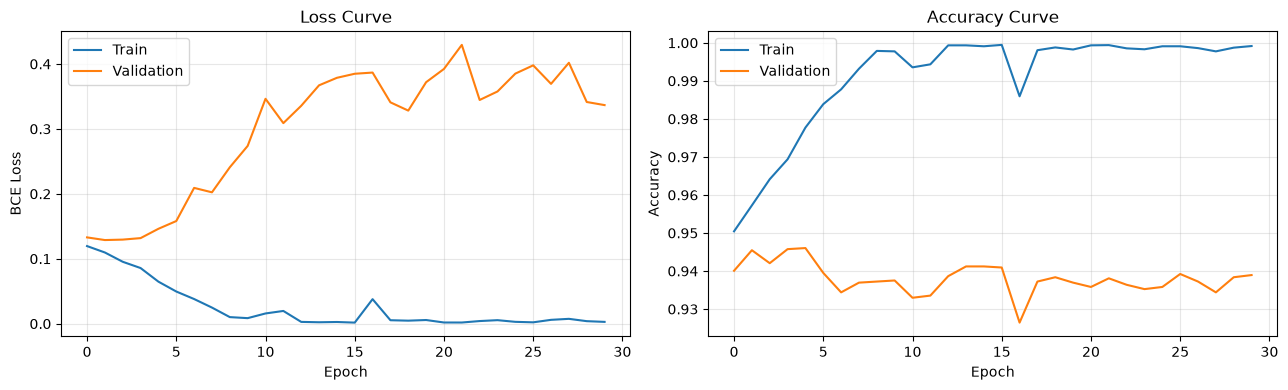

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(baseline_history["train_loss"], label="Train")
axes[0].plot(baseline_history["val_loss"], label="Validation")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(baseline_history["train_acc"], label="Train")
axes[1].plot(baseline_history["val_acc"], label="Validation")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Hyperparameter Experiments

So sánh:
- optimizer;
- learning rate;
- batch size;
- kích thước hidden layers.

Tiêu chí chọn model: **Validation F1**, sau đó đánh giá một lần trên Test.


In [18]:
configs = [
    ("GD",      (128,64,32,16), "gd",       0.01, 64, 15),
    ("Momentum",(128,64,32,16), "momentum", 0.01, 64, 15),
    ("Adam",    (128,64,32,16), "adam",     0.001, 64, 15),
    ("Adam BS32",(128,64,32,16),"adam",     0.001, 32, 15),
    ("Adam Deep",(256,128,64,32),"adam",    0.001, 64, 15),
    ("Adam Small",(64,32,16,8),"adam",      0.001, 64, 15),
]

dl_results = {}
dl_histories = {}

for name, hidden, opt, lr, bs, epochs in configs:
    print("\n", "="*60)
    print(name, hidden, opt, lr, bs)

    t0 = time.time()
    model = NeuralNetwork5Layers(
        INPUT_DIM, hidden_dims=hidden,
        optimizer=opt, learning_rate=lr, seed=SEED
    )

    history = train_nn(
        model, X_train_dl, y_train_dl,
        X_val_dl, y_val_dl,
        epochs=epochs, batch_size=bs, verbose=False
    )

    val_prob = model.predict_proba(X_val_dl).ravel()
    val_pred = (val_prob >= 0.5).astype(int)

    test_prob = model.predict_proba(X_test_dl).ravel()
    test_pred = (test_prob >= 0.5).astype(int)

    dl_results[name] = {
        "model": model,
        "optimizer": opt,
        "lr": lr,
        "batch": bs,
        "hidden": hidden,
        "params": model.count_params(),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
        "val_auc": roc_auc_score(y_val, val_prob),
        "test_acc": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_auc": roc_auc_score(y_test, test_prob),
        "time": time.time() - t0,
        "test_prob": test_prob,
        "test_pred": test_pred
    }
    dl_histories[name] = history

    print(
        f"Val F1={dl_results[name]['val_f1']:.4f} | "
        f"Test F1={dl_results[name]['test_f1']:.4f} | "
        f"Test AUC={dl_results[name]['test_auc']:.4f}"
    )



GD (128, 64, 32, 16) gd 0.01 64
Val F1=0.9622 | Test F1=0.9581 | Test AUC=0.9720

Momentum (128, 64, 32, 16) momentum 0.01 64
Val F1=0.9627 | Test F1=0.9577 | Test AUC=0.9717

Adam (128, 64, 32, 16) adam 0.001 64
Val F1=0.9609 | Test F1=0.9560 | Test AUC=0.9657

Adam BS32 (128, 64, 32, 16) adam 0.001 32
Val F1=0.9631 | Test F1=0.9593 | Test AUC=0.9650

Adam Deep (256, 128, 64, 32) adam 0.001 64
Val F1=0.9611 | Test F1=0.9577 | Test AUC=0.9668

Adam Small (64, 32, 16, 8) adam 0.001 64
Val F1=0.9616 | Test F1=0.9588 | Test AUC=0.9646


In [19]:
dl_comparison = pd.DataFrame({
    name: {
        "Architecture": "→".join(map(str, [INPUT_DIM, *r["hidden"], 1])),
        "Optimizer": r["optimizer"],
        "LR": r["lr"],
        "Batch": r["batch"],
        "Params": r["params"],
        "Val F1": r["val_f1"],
        "Val AUC": r["val_auc"],
        "Test Accuracy": r["test_acc"],
        "Test Precision": r["test_precision"],
        "Test Recall": r["test_recall"],
        "Test F1": r["test_f1"],
        "Test AUC": r["test_auc"],
        "Time (s)": r["time"]
    }
    for name, r in dl_results.items()
}).T

display(dl_comparison.round(4))


,Architecture,Optimizer,LR,Batch,Params,Val F1,Val AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Time (s)
GD,534→128→64→32→16→1,gd,0.01,64,79361,0.962175,0.975804,0.931818,0.968243,0.948169,0.958101,0.972024,29.012532
Momentum,534→128→64→32→16→1,momentum,0.01,64,79361,0.962717,0.97596,0.931534,0.972906,0.942985,0.957712,0.97167,29.777078
Adam,534→128→64→32→16→1,adam,0.001,64,79361,0.960869,0.971236,0.927273,0.951094,0.960954,0.955999,0.965651,34.288786
Adam BS32,534→128→64→32→16→1,adam,0.001,32,79361,0.963091,0.973327,0.933239,0.961792,0.956807,0.959293,0.964982,33.638715
Adam Deep,534→256→128→64→32→1,adam,0.001,64,180225,0.961066,0.975153,0.930398,0.956567,0.95888,0.957722,0.966836,52.784372
Adam Small,534→64→32→16→8→1,adam,0.001,64,36993,0.961585,0.971878,0.932102,0.956029,0.961645,0.958829,0.964591,11.079041


## 11. Chọn Best Deep Learning Model


In [20]:
best_dl_name = max(dl_results, key=lambda k: dl_results[k]["val_f1"])
best_dl = dl_results[best_dl_name]

print("Best DL:", best_dl_name)
print("Architecture:", best_dl["hidden"])
print("Optimizer:", best_dl["optimizer"])
print("Validation F1:", round(best_dl["val_f1"], 4))
print("Test F1:", round(best_dl["test_f1"], 4))
print("Test AUC:", round(best_dl["test_auc"], 4))


Best DL: Adam BS32
Architecture: (128, 64, 32, 16)
Optimizer: adam
Validation F1: 0.9631
Test F1: 0.9593
Test AUC: 0.965


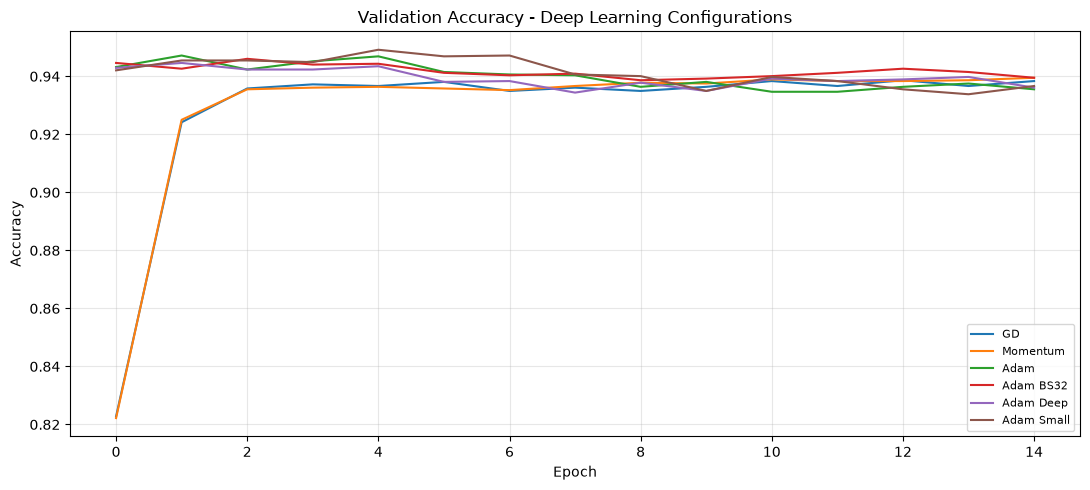

In [21]:
# Validation curves của các cấu hình
plt.figure(figsize=(11, 5))
for name, h in dl_histories.items():
    plt.plot(h["val_acc"], label=name)
plt.title("Validation Accuracy - Deep Learning Configurations")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. So sánh ML vs Deep Learning


In [22]:
all_compare = {}

for name, r in ml_results.items():
    all_compare["ML - " + name] = {
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "AUC": r["auc"],
        "Time (s)": r["time"]
    }

for name, r in dl_results.items():
    all_compare["DL - " + name] = {
        "Accuracy": r["test_acc"],
        "Precision": r["test_precision"],
        "Recall": r["test_recall"],
        "F1": r["test_f1"],
        "AUC": r["test_auc"],
        "Time (s)": r["time"]
    }

final_comparison = pd.DataFrame(all_compare).T.sort_values("F1", ascending=False)
display(final_comparison.round(4))


,Accuracy,Precision,Recall,F1,AUC,Time (s)
ML - Logistic Regression,0.9366,0.9581,0.9651,0.9616,0.9762,0.3311
DL - Adam BS32,0.9332,0.9618,0.9568,0.9593,0.9650,33.6387
DL - Adam Small,0.9321,0.9560,0.9616,0.9588,0.9646,11.0790
DL - GD,0.9318,0.9682,0.9482,0.9581,0.9720,29.0125
DL - Adam Deep,0.9304,0.9566,0.9589,0.9577,0.9668,52.7844
DL - Momentum,0.9315,0.9729,0.9430,0.9577,0.9717,29.7771
DL - Adam,0.9273,0.9511,0.9610,0.9560,0.9657,34.2888
ML - Random Forest,0.9233,0.9339,0.9758,0.9544,0.9710,2.1995


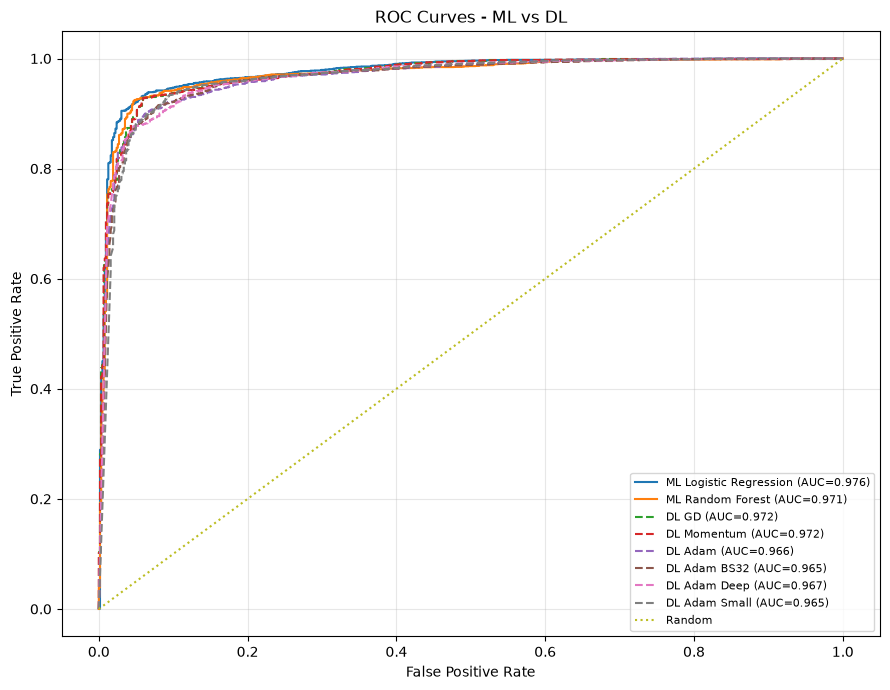

In [23]:
# ROC curves
plt.figure(figsize=(9, 7))

for name, r in ml_results.items():
    fpr, tpr, _ = roc_curve(y_test, r["prob"])
    plt.plot(fpr, tpr, label=f"ML {name} (AUC={r['auc']:.3f})")

for name, r in dl_results.items():
    fpr, tpr, _ = roc_curve(y_test, r["test_prob"])
    plt.plot(fpr, tpr, linestyle="--",
             label=f"DL {name} (AUC={r['test_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle=":", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - ML vs DL")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Confusion Matrix — Best DL


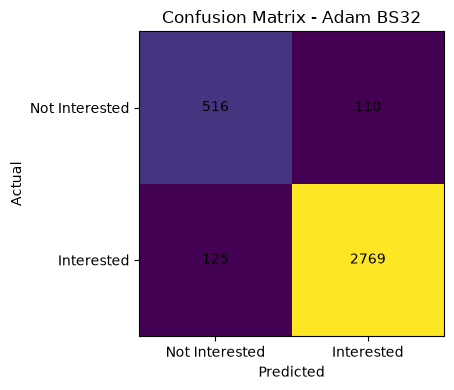

                precision    recall  f1-score   support

Not Interested       0.80      0.82      0.81       626
    Interested       0.96      0.96      0.96      2894

      accuracy                           0.93      3520
     macro avg       0.88      0.89      0.89      3520
  weighted avg       0.93      0.93      0.93      3520



In [24]:
cm = confusion_matrix(y_test, best_dl["test_pred"])

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_dl_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Not Interested", "Interested"])
plt.yticks([0, 1], ["Not Interested", "Interested"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    best_dl["test_pred"],
    target_names=["Not Interested", "Interested"],
    zero_division=0
))


## 14. Overfitting / Underfitting Analysis

Quan sát:
- Train loss vs Validation loss
- Train accuracy vs Validation accuracy

Nếu train tốt nhưng validation kém rõ rệt → có dấu hiệu overfitting.


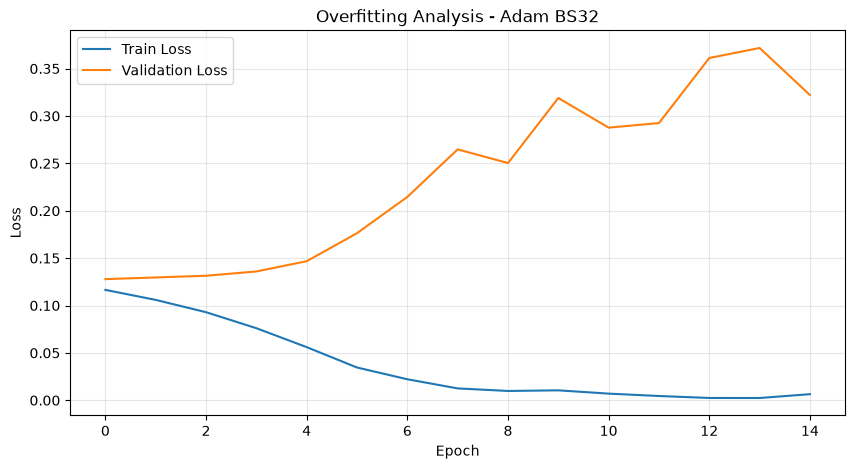

Final Train Accuracy: 0.9976
Final Validation Accuracy: 0.9395
Train-Val gap: 0.0581


In [25]:
h = dl_histories[best_dl_name]

plt.figure(figsize=(10, 5))
plt.plot(h["train_loss"], label="Train Loss")
plt.plot(h["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Overfitting Analysis - {best_dl_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

train_final = h["train_acc"][-1]
val_final = h["val_acc"][-1]
print("Final Train Accuracy:", round(train_final, 4))
print("Final Validation Accuracy:", round(val_final, 4))
print("Train-Val gap:", round(train_final - val_final, 4))


## 15. Feature Importance

Dùng Random Forest để xem nhóm feature nào đóng góp nhiều nhất.

Lưu ý: importance của TF-IDF được hiển thị theo từng vector index; đây là phân tích bổ trợ cho mô hình ML, không phải trọng số trực tiếp của neural network.


,Feature,Importance
2,Rating,0.402849
496,tfidf_462,0.024099
130,tfidf_96,0.020391
494,tfidf_460,0.017964
297,tfidf_263,0.014602
493,tfidf_459,0.013305
259,tfidf_225,0.013124
265,tfidf_231,0.010688
199,tfidf_165,0.009952
324,tfidf_290,0.009144


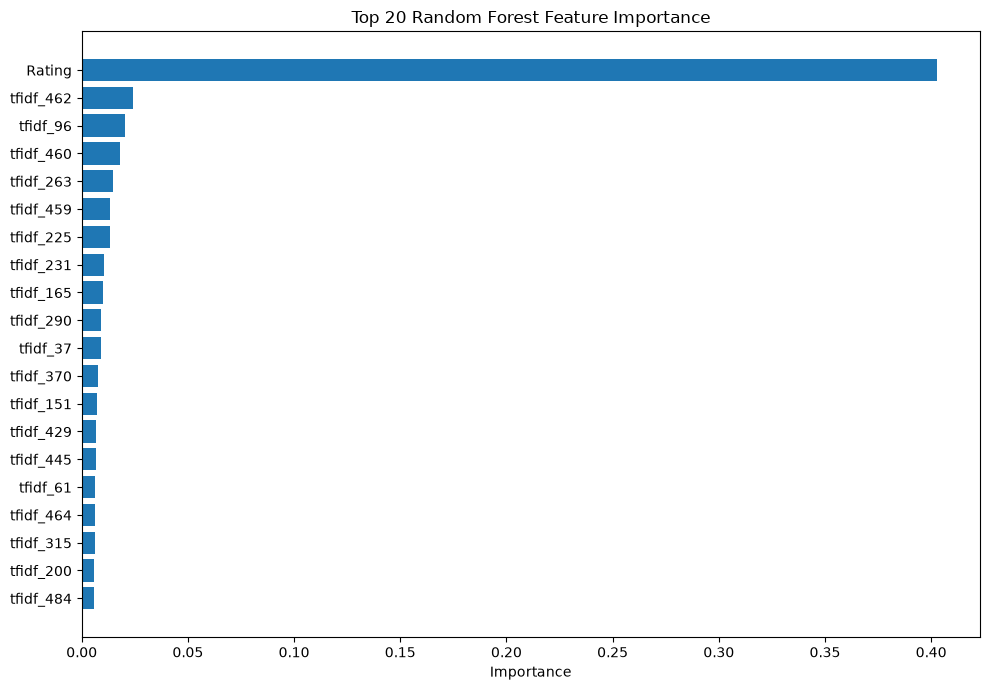

In [26]:
rf = ml_results["Random Forest"]["model"]
importances = rf.feature_importances_

cat_names = list(ohe.get_feature_names_out(cat_cols))
text_names = [f"tfidf_{i}" for i in range(X_train_txt.shape[1])]
feature_names = num_cols + cat_names + text_names

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feat_df.head(20))

top = feat_df.head(20).sort_values("Importance")
plt.figure(figsize=(10, 7))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.title("Top 20 Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 16. Save Model / Preprocessing

Lưu:
- trọng số neural network bằng `.npz`;
- scaler;
- encoder;
- TF-IDF vocabulary;
- thông tin kiến trúc.

Các file này có thể dùng tiếp cho bước triển khai web local.


In [27]:
from pathlib import Path
import pickle

MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)

# Save NumPy DL weights
np.savez(
    MODEL_DIR / "best_dl_ecommerce_weights.npz",
    **{f"W{i}": w for i, w in enumerate(best_dl["model"].W)},
    **{f"b{i}": b for i, b in enumerate(best_dl["model"].b)}
)

# Save preprocessing objects
with open(MODEL_DIR / "preprocessing.pkl", "wb") as f:
    pickle.dump({
        "scaler": scaler,
        "ohe": ohe,
        "tfidf": tfidf,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "input_dim": INPUT_DIM,
        "hidden_dims": best_dl["hidden"]
    }, f)

print("Saved:", MODEL_DIR / "best_dl_ecommerce_weights.npz")
print("Saved:", MODEL_DIR / "preprocessing.pkl")


Saved: saved_models\best_dl_ecommerce_weights.npz
Saved: saved_models\preprocessing.pkl


## 17. Final Conclusion

Notebook đã hoàn thành pipeline:

**Dataset → Inspection → Cleaning → Feature Engineering → Train/Val/Test → ML Baselines → Deep Learning NumPy from scratch → Hyperparameter Tuning → Evaluation → Model Saving**

Điểm quan trọng của bài:
- target là **user interest / recommendation** (`Recommended IND`);
- neural network được xây dựng thủ công bằng **NumPy**;
- không dùng TensorFlow, Keras hoặc PyTorch cho Deep Learning;
- có so sánh với Machine Learning truyền thống;
- có lưu model để sử dụng cho bước triển khai sau.


In [28]:
best_overall = final_comparison.index[0]
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print("Best overall model:", best_overall)
print(final_comparison.loc[best_overall].round(4))
print("\nBest DL:", best_dl_name)
print("Saved model directory:", MODEL_DIR.resolve())


FINAL SUMMARY
Best overall model: ML - Logistic Regression
Accuracy     0.9366
Precision    0.9581
Recall       0.9651
F1           0.9616
AUC          0.9762
Time (s)     0.3311
Name: ML - Logistic Regression, dtype: float64

Best DL: Adam BS32
Saved model directory: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 03\customer_behavior\saved_models
